## Step 0: Install packages and load data

In [ ]:
%pip install git+https://github.com/openai/CLIP.git
%pip install numpy pandas scikit-learn
#%pip install torch torchvision clip-by-openai numpy pandas scikit-learn

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-92is_9lg
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-92is_9lg
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=4d429f513bbccd14f66a3686a424098accf63a3dc1d76389804670f48077b295
  Stored in directory: /tmp/pip-ephem-wheel-cache-k7vy0i5b/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import os
import torch
import clip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Load datasets (download the datasets from canvas page https://ncl.instructure.com/courses/58651/files/9259194?wrap=1 )

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load datasets

!unzip "/content/drive/MyDrive/Advanced_AI/Task 2 NLP Dataset.zip" -d "/content/Task 2/"
fpath="/content/Task 2/"
train_path= fpath+"train/train.csv"
val_path= fpath+"val/val.csv"
test_path= fpath+"test/test.csv"
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

Archive:  /content/drive/MyDrive/Advanced_AI/Task 2 NLP Dataset.zip
   creating: /content/Task 2/test/
   creating: /content/Task 2/test/images/
  inflating: /content/Task 2/test/images/03293059977.png  
  inflating: /content/Task 2/test/images/04503363622.png  
  inflating: /content/Task 2/test/images/05850548023.png  
  inflating: /content/Task 2/test/images/08230960409.png  
  inflating: /content/Task 2/test/images/08929950286.png  
  inflating: /content/Task 2/test/images/09597167816.png  
  inflating: /content/Task 2/test/images/12319434549.png  
  inflating: /content/Task 2/test/images/13914680332.png  
  inflating: /content/Task 2/test/images/16351831695.png  
  inflating: /content/Task 2/test/images/19861926689.png  
  inflating: /content/Task 2/test/images/20825217491.png  
  inflating: /content/Task 2/test/images/23865135757.png  
  inflating: /content/Task 2/test/images/29100342345.png  
  inflating: /content/Task 2/test/images/33246843335.png  
  inflating: /content/Task 2/

In [ ]:
# show the data
print (test_df)

             compound sentence_type  \
0         dirty money     idiomatic   
1         dirty money     idiomatic   
2         dirty money     idiomatic   
3        secret santa     idiomatic   
4        secret santa     idiomatic   
5        secret santa     idiomatic   
6         ivory tower     idiomatic   
7         ivory tower     idiomatic   
8         ivory tower     idiomatic   
9   low-hanging fruit     idiomatic   
10  low-hanging fruit     idiomatic   
11  low-hanging fruit     idiomatic   
12         brass ring     idiomatic   
13         brass ring     idiomatic   
14         brass ring     idiomatic   
15      silver bullet     idiomatic   
16      silver bullet     idiomatic   
17      silver bullet     idiomatic   
18      peas in a pod     idiomatic   
19      peas in a pod     idiomatic   
20      peas in a pod     idiomatic   
21        green light     idiomatic   
22        green light     idiomatic   
23        green light     idiomatic   
24           busy bee    

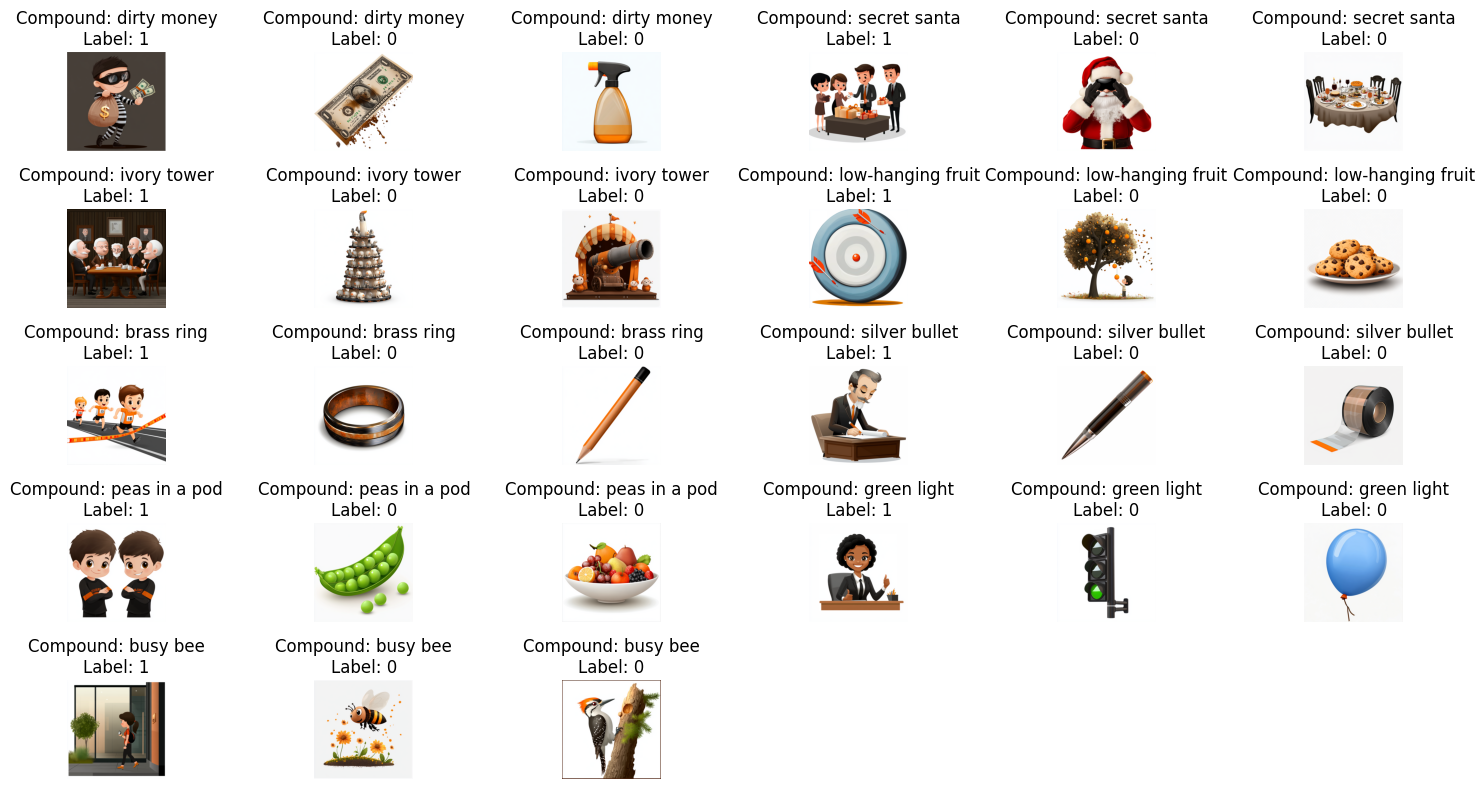

In [ ]:
# Visualise dataset. Note please don't try to visualize the whole training set, as there are many images.
image_folder = fpath+"test/images"

def visualise_data(df, image_folder):
    fig, axes = plt.subplots(len(df)//6+1, 6, figsize=(15, 8))
    axes = axes.flatten()

    for idx, row in df.iterrows():
        image_path = os.path.join(image_folder, row['image_name'])
        try:
            img = Image.open(image_path)
            ax = axes[idx]
            ax.imshow(img)
            ax.set_title(f"Compound: {row['compound']}\nLabel: {row['label']}")
            ax.axis('off')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")

    # Hide any empty subplots (those beyond the dataset size)
    for idx in range(len(df), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

visualise_data(test_df, fpath+"test/images")


Example code of Evaluation. You can use it directly or write your own.

In [ ]:
# Add this to your evaluate() function call to avoid silent 0s
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(df):
    metrics = {
        "accuracy":  accuracy_score(df["label"], df["prediction"]),
        "precision": precision_score(df["label"], df["prediction"], zero_division=0),
        "recall":    recall_score(df["label"],    df["prediction"], zero_division=0),
        "f1_score":  f1_score(df["label"],        df["prediction"], zero_division=0)
    }
    return metrics

## Step 1: NLP Exploratory Data Analysis

Train: 231 rows | 77 compounds | label=1: 77 (33%) | label=0: 154
Val: 27 rows | 9 compounds | label=1: 9 (33%) | label=0: 18
Test: 27 rows | 9 compounds | label=1: 9 (33%) | label=0: 18

--- Compounds in TRAIN ---
compound
hot potato         3
act of god         3
chicken feed       3
thin ice           3
eager beaver       3
                  ..
guinea pig         3
copy cat           3
armchair critic    3
heart of gold      3
watering hole      3
Name: count, Length: 77, dtype: int64

--- Compounds in VAL ---
compound
high life             3
loan shark            3
snake in the grass    3
ancient history       3
shrinking violet      3
acid test             3
dirty word            3
devil's advocate      3
rat run               3
Name: count, dtype: int64

--- Compounds in TEST ---
compound
dirty money          3
secret santa         3
ivory tower          3
low-hanging fruit    3
brass ring           3
silver bullet        3
peas in a pod        3
green light          3
busy bee  

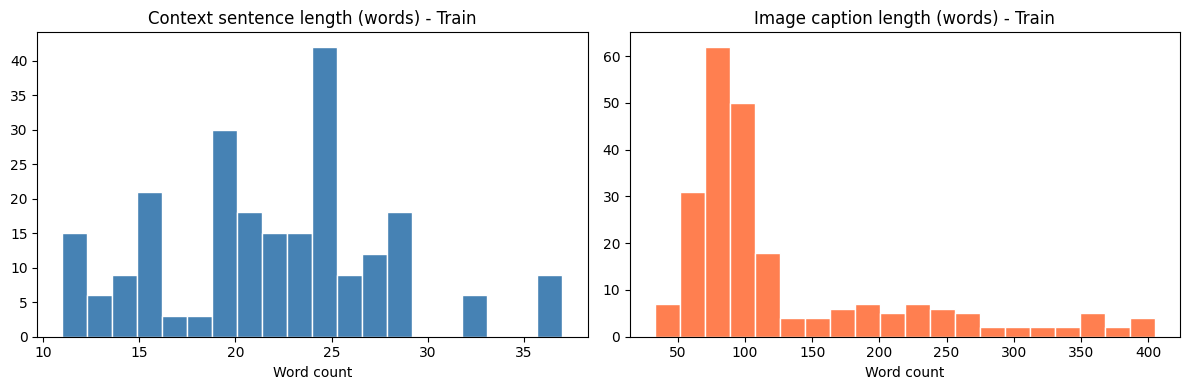


Compound string found in sentence: 98.7% of train rows

Top 15 words in MATCHING captions (label=1):
[('the', 875), ('and', 400), ('with', 164), ('image', 124), ('are', 103), ('depicts', 76), ('has', 74), ('white', 63), ('black', 62), ('character', 60), ('wearing', 60), ('scene', 59), ('appears', 58), ('that', 58), ('there', 52)]

Top 15 words in NON-MATCHING captions (label=0):
[('the', 1812), ('and', 826), ('with', 449), ('image', 234), ('are', 218), ('has', 159), ('white', 155), ('depicts', 152), ('orange', 129), ('which', 122), ('black', 120), ('its', 107), ('overall', 107), ('that', 104), ('there', 103)]

Words most distinctive of MATCHING captions:
  bar: 23.00x more common in label=1
  chairs: 10.00x more common in label=1
  bottles: 9.00x more common in label=1
  mud: 9.00x more common in label=1
  desks: 9.00x more common in label=1
  older: 8.00x more common in label=1
  construction: 7.33x more common in label=1
  tiger: 7.00x more common in label=1
  workers: 7.00x more co

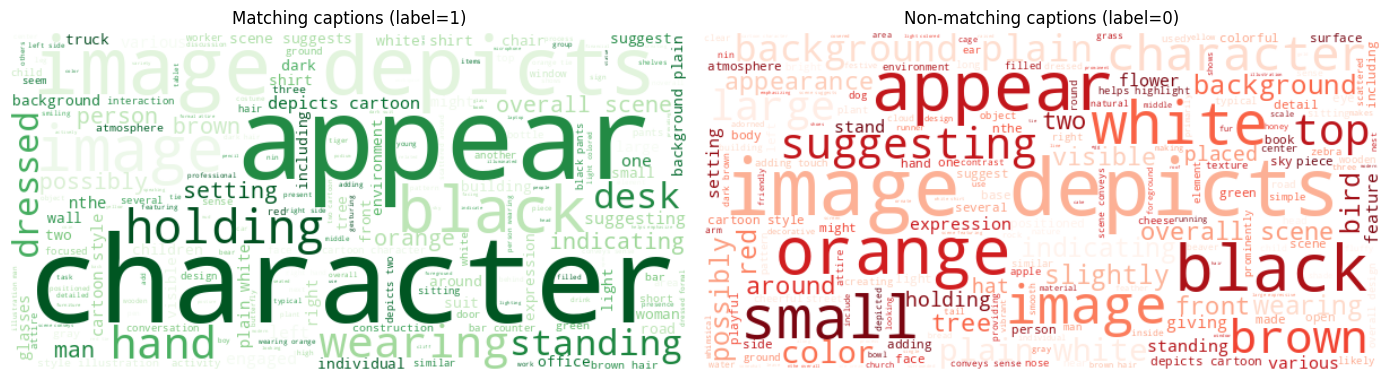

In [ ]:
# NLP Exploratory Data Analysis
#   - Compound variety and frequency
#   - Class balance
#   - Sentence and caption length distributions
#   - Vocabulary in matching vs non-matching captions

import re
import collections
import matplotlib.pyplot as plt

from wordcloud import WordCloud

# Dataset overview
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    n_compounds = df["compound"].nunique()
    n_pos = (df["label"] == 1).sum()
    n_neg = (df["label"] == 0).sum()
    print(f"{name}: {len(df)} rows | {n_compounds} compounds | label=1: {n_pos} ({n_pos/len(df)*100:.0f}%) | label=0: {n_neg}")

# Compounds per split
print("\n--- Compounds in TRAIN ---")
print(train_df["compound"].value_counts())

print("\n--- Compounds in VAL ---")
print(val_df["compound"].value_counts())

print("\n--- Compounds in TEST ---")
print(test_df["compound"].value_counts())

# Check for compound overlap between splits
train_compounds = set(train_df["compound"].unique())
val_compounds   = set(val_df["compound"].unique())
test_compounds  = set(test_df["compound"].unique())
print(f"\nTrain/val overlap: {train_compounds & val_compounds}")
print(f"Train/test overlap: {train_compounds & test_compounds}")
print(f"Val/test overlap:   {val_compounds & test_compounds}")

# Sentence length
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    df = df.copy()
    df["sent_len"]    = df["sentence"].apply(lambda x: len(x.split()))
    df["caption_len"] = df["image_caption"].apply(lambda x: len(x.split()))
    print(f"\n{name} - sentence: mean={df['sent_len'].mean():.1f}, "
          f"min={df['sent_len'].min()}, max={df['sent_len'].max()} | "
          f"caption: mean={df['caption_len'].mean():.1f}, "
          f"min={df['caption_len'].min()}, max={df['caption_len'].max()}")

# Plot length distributions for train
train_df_eda = train_df.copy()
train_df_eda["sent_len"]    = train_df_eda["sentence"].apply(lambda x: len(x.split()))
train_df_eda["caption_len"] = train_df_eda["image_caption"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df_eda["sent_len"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Context sentence length (words) - Train")
axes[0].set_xlabel("Word count")
axes[1].hist(train_df_eda["caption_len"], bins=20, color="coral", edgecolor="white")
axes[1].set_title("Image caption length (words) - Train")
axes[1].set_xlabel("Word count")
plt.tight_layout()
plt.show()

def compound_in_sentence(row):
    return row["compound"].lower() in row["sentence"].lower()

train_df_eda["compound_present"] = train_df_eda.apply(compound_in_sentence, axis=1)
pct = train_df_eda["compound_present"].mean() * 100
print(f"\nCompound string found in sentence: {pct:.1f}% of train rows")

# Vocabulary analysis: matching vs non-matching captions
def get_words(texts):
    words = []
    for t in texts:
        words.extend(re.findall(r'\b[a-z]{3,}\b', t.lower()))
    return words

pos_words = get_words(train_df[train_df["label"] == 1]["image_caption"])
neg_words = get_words(train_df[train_df["label"] == 0]["image_caption"])
pos_freq  = collections.Counter(pos_words)
neg_freq  = collections.Counter(neg_words)

print("\nTop 15 words in MATCHING captions (label=1):")
print(pos_freq.most_common(15))
print("\nTop 15 words in NON-MATCHING captions (label=0):")
print(neg_freq.most_common(15))

# Words distinctively more common in matching captions
all_words = set(pos_freq) | set(neg_freq)
distinctive = {
    w: pos_freq[w] / (neg_freq[w] + 1)
    for w in all_words if pos_freq[w] >= 3
}
print("\nWords most distinctive of MATCHING captions:")
for w, r in sorted(distinctive.items(), key=lambda x: -x[1])[:15]:
    print(f"  {w}: {r:.2f}x more common in label=1")

# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
wc_pos = WordCloud(width=600, height=300, background_color="white", colormap="Greens")
wc_pos.generate(" ".join(pos_words))
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Matching captions (label=1)")
axes[0].axis("off")

wc_neg = WordCloud(width=600, height=300, background_color="white", colormap="Reds")
wc_neg.generate(" ".join(neg_words))
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Non-matching captions (label=0)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


##Step 2: LLM based Data Augmentation.

In [ ]:
# LLM-based Data Augmentation using Groq

%pip install -q groq

from groq import Groq
import json, re, time
import pandas as pd

# Configure Groq
GROQ_API_KEY = ""
groq_client  = Groq(api_key=GROQ_API_KEY)


# Prompt builder
def build_prompt(compound, n_groups=2):
    return f"""You are building a dataset for multimodal idiom understanding.

The idiomatic compound expression is: "{compound}"

Generate {n_groups} new training examples. Each example must have:
- A sentence using "{compound}" in its IDIOMATIC (figurative) sense
- ONE image caption that correctly represents the idiomatic meaning (label 1)
- TWO image captions describing unrelated or literal images that do NOT match the idiom (label 0)

Respond ONLY with a valid JSON array. No explanation, no markdown, no code fences:
[
  {{
    "compound": "{compound}",
    "sentence": "...",
    "matching_caption": "...",
    "non_matching_caption_1": "...",
    "non_matching_caption_2": "..."
  }}
]"""


# Response parser
def parse_response(raw):
    raw   = re.sub(r"```json|```", "", raw).strip()
    match = re.search(r'\[.*\]', raw, re.DOTALL)
    if match:
        raw = match.group(0)
    return json.loads(raw)


# Main augmentation function
def augment_compound(compound, n_groups=2):
    response = groq_client.chat.completions.create(
        model = "llama-3.1-8b-instant",
        messages = [{"role": "user", "content": build_prompt(compound, n_groups)}],
        max_tokens      = 1000,
        temperature     = 0.8,
        response_format = {"type": "json_object"}
    )
    raw = response.choices[0].message.content.strip()

    parsed = json.loads(raw)
    if isinstance(parsed, list):
        return parsed

    for v in parsed.values():
        if isinstance(v, list):
            return v
    raise ValueError(f"Unexpected JSON structure: {list(parsed.keys())}")


# Run over all unique compounds in training set
augmented_rows   = []
failed_compounds = []
unique_compounds = train_df["compound"].unique()

print(f"Augmenting {len(unique_compounds)} compounds...\n")

for i, compound in enumerate(unique_compounds):
    print(f"[{i+1}/{len(unique_compounds)}] '{compound}'...", end=" ", flush=True)
    try:
        examples = augment_compound(compound, n_groups=2)
        for ex in examples:
            augmented_rows.append({
                "compound":      ex["compound"],
                "sentence_type": "idiomatic",
                "sentence":      ex["sentence"],
                "image_name":    "augmented",
                "image_caption": ex["matching_caption"],
                "label":         1
            })
            for key in ["non_matching_caption_1", "non_matching_caption_2"]:
                augmented_rows.append({
                    "compound":      ex["compound"],
                    "sentence_type": "idiomatic",
                    "sentence":      ex["sentence"],
                    "image_name":    "augmented",
                    "image_caption": ex[key],
                    "label":         0
                })
        print(f"OK - {len(examples)} groups added")
    except Exception as e:
        print(f"FAILED - {e}")
        failed_compounds.append(compound)

    time.sleep(2.0)


# Review and merge
aug_df = pd.DataFrame(augmented_rows)

print(f"\n{'='*50}")
print(f"Augmentation complete")
print(f"  New rows generated : {len(aug_df)}")
print(f"  Positive (label=1) : {(aug_df['label']==1).sum()}")
print(f"  Negative (label=0) : {(aug_df['label']==0).sum()}")
print(f"  Label ratio        : {aug_df['label'].mean():.2f} (should be ~0.33)")
if failed_compounds:
    print(f"  Failed compounds   : {failed_compounds}")

print("\nSample augmented rows:")
print(aug_df[["compound", "sentence", "image_caption", "label"]].head(9).to_string(index=False))

# Merge with original training data
train_augmented_df = pd.concat([train_df, aug_df], ignore_index=True).reset_index(drop=True)

print(f"\nFinal training set:")
print(f"  Original rows  : {len(train_df)}")
print(f"  Augmented rows : {len(aug_df)}")
print(f"  Total          : {len(train_augmented_df)}")
print(f"  Label ratio    : {train_augmented_df['label'].mean():.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 8.4 MB/s eta 0:00:00
Augmenting 77 compounds...

[1/77] 'hot potato'... OK - 2 groups added
[2/77] 'act of god'... OK - 2 groups added
[3/77] 'chicken feed'... OK - 2 groups added
[4/77] 'thin ice'... OK - 2 groups added
[5/77] 'eager beaver'... OK - 2 groups added
[6/77] 'big cheese'... OK - 2 groups added
[7/77] 'old flame'... OK - 2 groups added
[8/77] 'nest egg'... OK - 2 groups added
[9/77] 'hen party'... OK - 2 groups added
[10/77] 'pins and needles'... FAILED - 'compound'
[11/77] 'sour grapes'... OK - 2 groups added
[12/77] 'party animal'... OK - 2 groups added
[13/77] 'flea market'... OK - 2 groups added
[14/77] 'top dog'... OK - 2 groups added
[15/77] 'flying saucer'... OK - 2 groups added
[16/77] 'banana republic'... OK - 2 groups added
[17/77] 'bad apple'... OK - 2 groups added
[18/77] 'couch potato'... OK - 2 groups added
[19/77] 'white hat'... OK - 3 groups added
[20/77] 'spring chicken'... OK - 2 groups added
[21/

##Step 3: Zero-shot prediction. Write down your code here


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

=== 1: Zero-shot SBERT (text only) ===
  Val  - Acc: 0.556  P: 0.333  R: 0.333  F1: 0.333
  Test - Acc: 0.556  P: 0.333  R: 0.333  F1: 0.333


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 88.8MiB/s]



=== 3B: Zero-shot CLIP (multimodal) ===
  Val  - Acc: 0.481  P: 0.222  R: 0.222  F1: 0.222
  Test - Acc: 0.333  P: 0.0  R: 0.0  F1: 0.0

=== 3C: Zero-shot Combined (SBERT 70% + CLIP 30%) ===
  Val  - Acc: 0.556  P: 0.333  R: 0.333  F1: 0.333
  Test - Acc: 0.481  P: 0.222  R: 0.222  F1: 0.222

=== Zero-shot Summary ===
                Method  Val Acc  Val P  Val R  Val F1  Test Acc  Test P  Test R  Test F1
       Random baseline    0.333  0.333  0.333   0.333     0.333   0.333   0.333    0.333
 3A: SBERT (text only)    0.556  0.333  0.333   0.333     0.556   0.333   0.333    0.333
 3B: CLIP (multimodal)    0.481  0.222  0.222   0.222     0.333   0.000   0.000    0.000
3C: SBERT+CLIP (70/30)    0.556  0.333  0.333   0.333     0.481   0.222   0.222    0.222


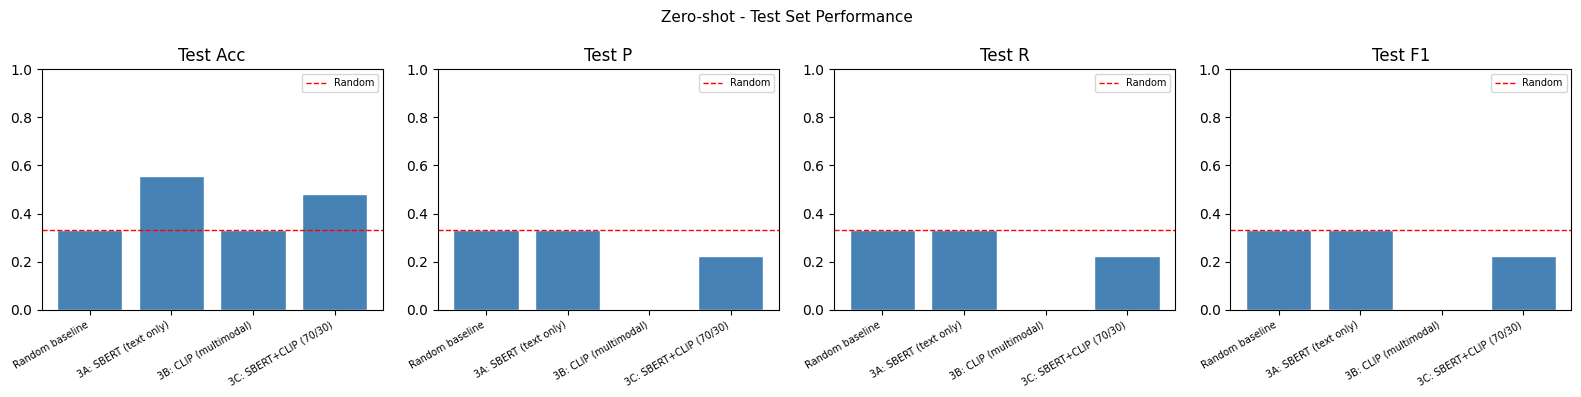

In [ ]:
# Zero-shot Prediction
#
# Three approaches:
#   3A - SBERT: compare sentence vs each image caption (text only)
#   3B - CLIP:  compare sentence vs each actual image (multimodal)
#   3C - Combined: weighted average of 3A and 3B scores

%pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import torch
import numpy as np

# Predict one label=1 per group of 3
def predict_by_similarity(df, sim_fn):

    df          = df.copy().reset_index(drop=True)
    predictions = [0] * len(df)

    for (compound, sentence), group in df.groupby(["compound", "sentence"]):
        idxs        = group.index.tolist()
        captions    = group["image_caption"].tolist()
        image_names = group["image_name"].tolist()
        sims        = sim_fn(sentence, captions, image_names)
        predictions[idxs[int(np.argmax(sims))]] = 1

    df["prediction"] = predictions
    return df

def get_metrics(m):
    return {k: round(v, 3) for k, v in m.items()}

# APPROACH 3A: Text-only (Sentence-BERT)
# Encodes the sentence and each caption, picks the closest one
sbert = SentenceTransformer("all-MiniLM-L6-v2")

def sbert_sim(sentence, captions, image_names):
    embs = sbert.encode([sentence] + captions, convert_to_numpy=True)
    return cosine_similarity(embs[0:1], embs[1:])[0]

val_3a  = predict_by_similarity(val_df,  sbert_sim)
test_3a = predict_by_similarity(test_df, sbert_sim)
m_val_3a, m_test_3a = get_metrics(evaluate(val_3a)), get_metrics(evaluate(test_3a))

print("=== 1: Zero-shot SBERT (text only) ===")
print(f"  Val  - Acc: {m_val_3a['accuracy']}  P: {m_val_3a['precision']}  R: {m_val_3a['recall']}  F1: {m_val_3a['f1_score']}")
print(f"  Test - Acc: {m_test_3a['accuracy']}  P: {m_test_3a['precision']}  R: {m_test_3a['recall']}  F1: {m_test_3a['f1_score']}")

# APPROACH 3B: Multimodal (CLIP)
# Encodes the sentence as text and compares against each image
clip_model, preprocess_clip = clip.load("ViT-B/32", device="cpu")

def get_clip_image_emb(image_path):
    try:
        img = preprocess_clip(Image.open(image_path)).unsqueeze(0)
        with torch.no_grad():
            return clip_model.encode_image(img).float().numpy()[0]
    except Exception:
        return np.zeros(512)

def clip_sim(sentence, captions, image_names, image_folder):
    # Encode sentence with CLIP text encoder
    token    = clip.tokenize([sentence], truncate=True)
    with torch.no_grad():
        text_emb = clip_model.encode_text(token).float().numpy()

    # Encode each image with CLIP image encoder
    img_embs = []
    for name in image_names:
        try:
            img = preprocess_clip(Image.open(os.path.join(image_folder, name))).unsqueeze(0)
            with torch.no_grad():
                emb = clip_model.encode_image(img).float().numpy()[0]
        except Exception:
            emb = np.zeros(512)
        img_embs.append(emb)

    return cosine_similarity(text_emb, np.array(img_embs))[0]

# Wrap with folder paths for each split
def clip_sim_val(sentence, captions, image_names):
    return clip_sim(sentence, captions, image_names, fpath + "val/images")

def clip_sim_test(sentence, captions, image_names):
    return clip_sim(sentence, captions, image_names, fpath + "test/images")

val_3b  = predict_by_similarity(val_df,  clip_sim_val)
test_3b = predict_by_similarity(test_df, clip_sim_test)
m_val_3b, m_test_3b = get_metrics(evaluate(val_3b)), get_metrics(evaluate(test_3b))

print("\n=== 3B: Zero-shot CLIP (multimodal) ===")
print(f"  Val  - Acc: {m_val_3b['accuracy']}  P: {m_val_3b['precision']}  R: {m_val_3b['recall']}  F1: {m_val_3b['f1_score']}")
print(f"  Test - Acc: {m_test_3b['accuracy']}  P: {m_test_3b['precision']}  R: {m_test_3b['recall']}  F1: {m_test_3b['f1_score']}")

# APPROACH 3C: Weighted combination (SBERT 70% + CLIP 30%)

def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

def combined_sim_val(sentence, captions, image_names):
    return 0.7 * norm(sbert_sim(sentence, captions, image_names)) + \
           0.3 * norm(clip_sim_val(sentence, captions, image_names))

def combined_sim_test(sentence, captions, image_names):
    return 0.7 * norm(sbert_sim(sentence, captions, image_names)) + \
           0.3 * norm(clip_sim_test(sentence, captions, image_names))

val_3c  = predict_by_similarity(val_df,  combined_sim_val)
test_3c = predict_by_similarity(test_df, combined_sim_test)
m_val_3c, m_test_3c = get_metrics(evaluate(val_3c)), get_metrics(evaluate(test_3c))

print("\n=== 3C: Zero-shot Combined (SBERT 70% + CLIP 30%) ===")
print(f"  Val  - Acc: {m_val_3c['accuracy']}  P: {m_val_3c['precision']}  R: {m_val_3c['recall']}  F1: {m_val_3c['f1_score']}")
print(f"  Test - Acc: {m_test_3c['accuracy']}  P: {m_test_3c['precision']}  R: {m_test_3c['recall']}  F1: {m_test_3c['f1_score']}")

# Summary table = all zero-shot methods + random baseline
zeroshot_summary = pd.DataFrame([
    {"Method": "Random baseline",           "Val Acc": 0.333, "Val P": 0.333, "Val R": 0.333, "Val F1": 0.333,
                                             "Test Acc": 0.333, "Test P": 0.333, "Test R": 0.333, "Test F1": 0.333},
    {"Method": "3A: SBERT (text only)",     "Val Acc": m_val_3a["accuracy"],  "Val P": m_val_3a["precision"],  "Val R": m_val_3a["recall"],  "Val F1": m_val_3a["f1_score"],
                                             "Test Acc": m_test_3a["accuracy"], "Test P": m_test_3a["precision"], "Test R": m_test_3a["recall"], "Test F1": m_test_3a["f1_score"]},
    {"Method": "3B: CLIP (multimodal)",     "Val Acc": m_val_3b["accuracy"],  "Val P": m_val_3b["precision"],  "Val R": m_val_3b["recall"],  "Val F1": m_val_3b["f1_score"],
                                             "Test Acc": m_test_3b["accuracy"], "Test P": m_test_3b["precision"], "Test R": m_test_3b["recall"], "Test F1": m_test_3b["f1_score"]},
    {"Method": "3C: SBERT+CLIP (70/30)",    "Val Acc": m_val_3c["accuracy"],  "Val P": m_val_3c["precision"],  "Val R": m_val_3c["recall"],  "Val F1": m_val_3c["f1_score"],
                                             "Test Acc": m_test_3c["accuracy"], "Test P": m_test_3c["precision"], "Test R": m_test_3c["recall"], "Test F1": m_test_3c["f1_score"]},
])

print("\n=== Zero-shot Summary ===")
print(zeroshot_summary.to_string(index=False))

# Bar chart - test set metrics
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
methods   = zeroshot_summary["Method"]

for ax, metric in zip(axes, ["Test Acc", "Test P", "Test R", "Test F1"]):
    ax.bar(range(len(methods)), zeroshot_summary[metric], color="steelblue", edgecolor="white")
    ax.axhline(0.333, color="red", linestyle="--", linewidth=1, label="Random")
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=30, ha="right", fontsize=7)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

plt.suptitle("Zero-shot - Test Set Performance", fontsize=11)
plt.tight_layout()
plt.show()

##Step 4: Fine-tuning based and other prediction approaches. Write down your code here.

4A: Fine-tuning Sentence-BERT


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Val Cosine Accuracy,Val Cosine Accuracy Threshold,Val Cosine F1,Val Cosine F1 Threshold,Val Cosine Precision,Val Cosine Recall,Val Cosine Ap,Val Cosine Mcc
43,No log,No log,0.814815,0.450522,0.666667,0.450522,0.833333,0.555556,0.684829,0.566947
86,No log,No log,0.925926,0.511264,0.888889,0.511264,0.888889,0.888889,0.786680,0.833333
129,No log,No log,0.851852,0.542201,0.777778,0.525648,0.777778,0.777778,0.695631,0.666667
172,No log,No log,0.851852,0.530953,0.800000,0.433313,0.727273,0.888889,0.689935,0.692902
215,No log,No log,0.851852,0.533750,0.800000,0.426686,0.727273,0.888889,0.689935,0.692902


/usr/local/lib/python3.12/dist-packages/sentence_transformers/util/tensor.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  a = torch.tensor(a)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Val  - Acc: 0.926  P: 0.889  R: 0.889  F1: 0.889
Test - Acc: 1.0  P: 1.0  R: 1.0  F1: 1.0

4B: CLIP Embeddings + Logistic Regression
Extracting CLIP features...
Val  - Acc: 0.778  P: 0.667  R: 0.667  F1: 0.667
Test - Acc: 0.778  P: 0.667  R: 0.667  F1: 0.667

4C: Fine-tuned CLIP (contrastive training)
Using device: cuda
  Epoch 1/5 - loss: 0.7278 | Val Acc: 0.481
     Best checkpoint saved (epoch 1)
  Epoch 2/5 - loss: 0.7124 | Val Acc: 0.481
  Epoch 3/5 - loss: 0.6940 | Val Acc: 0.556
     Best checkpoint saved (epoch 3)
  Epoch 4/5 - loss: 0.6707 | Val Acc: 0.630
     Best checkpoint saved (epoch 4)
  Epoch 5/5 - loss: 0.6506 | Val Acc: 0.778
     Best checkpoint saved (epoch 5)

Best epoch: 5 | Best Val Acc: 0.778

Val  - Acc: 0.778  P: 0.667  R: 0.667  F1: 0.667
Test - Acc: 0.778  P: 0.667  R: 0.667  F1: 0.667

FINAL RESULTS - ALL METHODS
                  Method  Val Acc  Val P  Val R  Val F1  Test Acc  Test P  Test R  Test F1
         Random baseline    0.333  0.333  0.333   0.3

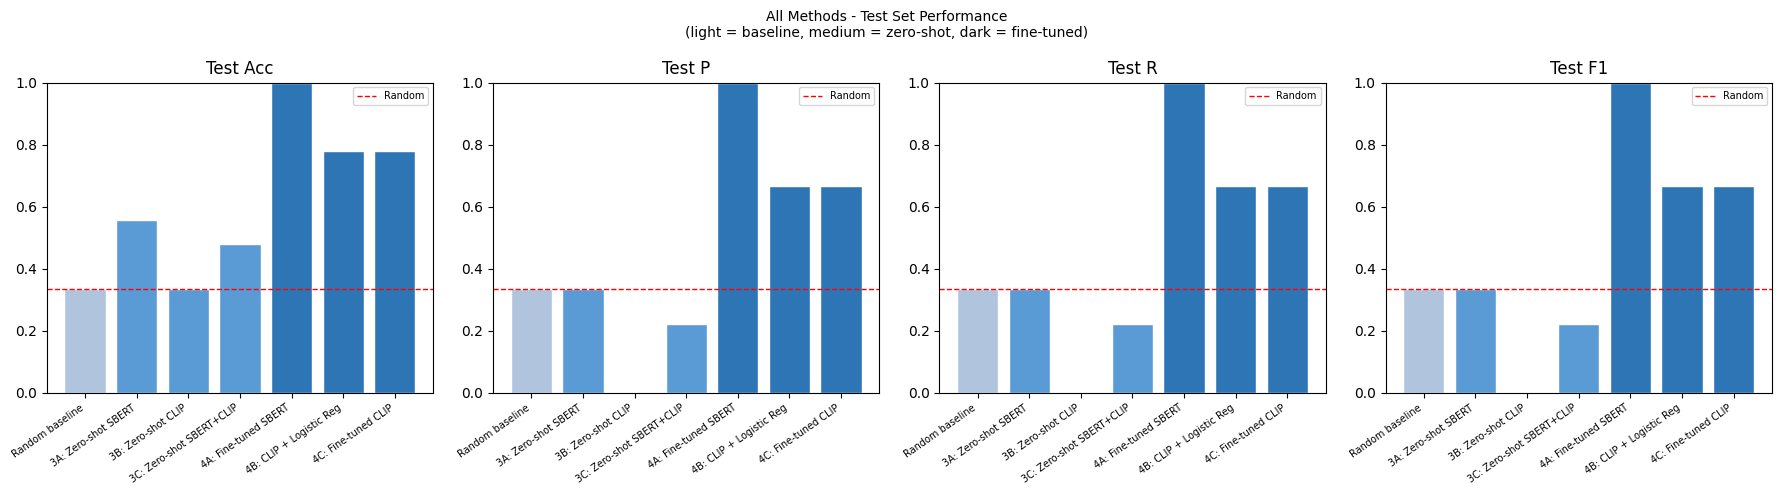

In [ ]:
# Fine-tuning based and other prediction approaches
#
# Three approaches:
#   4A - Fine-tuned Sentence-BERT
#        Trains SBERT on (sentence, caption) pairs from
#        augmented data to better score idiomatic matches
#   4B - CLIP Embeddings with Logistic Regression
#        Extracts frozen CLIP features and trains a lightweight
#        classifier on top
#   4C - Fine-tuned CLIP
#        Trains CLIP text encoder to align idiomatic sentences
#        with their correct images

%pip install -q sentence-transformers scikit-learn

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import BinaryClassificationEvaluator
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader as TorchDataLoader, Dataset
import torch.nn as nn
import torch.optim as optim


# APPROACH 4A: Fine-tuned Sentence-BERT
# Trains SBERT on (sentence, caption) pairs using cosine
# similarity loss
print("=" * 55)
print("4A: Fine-tuning Sentence-BERT")
print("=" * 55)

train_examples_4a = [
    InputExample(
        texts=[row["sentence"], row["image_caption"]],
        label=float(row["label"])
    )
    for _, row in train_augmented_df.iterrows()
]

# Val evaluator
val_evaluator_4a = BinaryClassificationEvaluator(
    sentences1=val_df["sentence"].tolist(),
    sentences2=val_df["image_caption"].tolist(),
    labels=val_df["label"].tolist(),
    name="val"
)

# Load base model, define loss, fine-tune
sbert_ft = SentenceTransformer("all-MiniLM-L6-v2")
train_dl = TorchDataLoader(train_examples_4a, shuffle=True, batch_size=16)
loss_fn  = losses.CosineSimilarityLoss(sbert_ft)

sbert_ft.fit(
    train_objectives  = [(train_dl, loss_fn)],
    evaluator         = val_evaluator_4a,
    epochs            = 5,
    warmup_steps      = int(len(train_dl) * 0.1),
    output_path       = "/content/sbert_finetuned",
    show_progress_bar = True
)

# Load best checkpoint selected by val performance
sbert_best = SentenceTransformer("/content/sbert_finetuned")

def sbert_ft_sim(sentence, captions, image_names):
    embs = sbert_best.encode([sentence] + captions, convert_to_numpy=True)
    return cosine_similarity(embs[0:1], embs[1:])[0]

# Evaluate on val, then test
val_4a    = predict_by_similarity(val_df,  sbert_ft_sim)
test_4a   = predict_by_similarity(test_df, sbert_ft_sim)
m_val_4a  = get_metrics(evaluate(val_4a))
m_test_4a = get_metrics(evaluate(test_4a))

print(f"\nVal  - Acc: {m_val_4a['accuracy']}  P: {m_val_4a['precision']}  R: {m_val_4a['recall']}  F1: {m_val_4a['f1_score']}")
print(f"Test - Acc: {m_test_4a['accuracy']}  P: {m_test_4a['precision']}  R: {m_test_4a['recall']}  F1: {m_test_4a['f1_score']}")


# APPROACH 4B: CLIP Embeddings + Logistic Regression
# Extracts frozen CLIP text + image features and trains a
# logistic regression classifier on top.

print("\n" + "=" * 55)
print("4B: CLIP Embeddings + Logistic Regression")
print("=" * 55)

def get_clip_text_embs(texts, batch_size=32):
    """Encode texts with CLIP in batches, returns numpy array."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        tokens = clip.tokenize(texts[i:i+batch_size], truncate=True)
        with torch.no_grad():
            all_embs.append(clip_model.encode_text(tokens).float().numpy())
    return np.vstack(all_embs)

def build_clip_features(df, image_folder):

    sent_embs = get_clip_text_embs(df["sentence"].tolist())
    cap_embs  = get_clip_text_embs(df["image_caption"].tolist())
    img_embs  = np.array([
        get_clip_image_emb(os.path.join(image_folder, name))
        if name != "augmented" else np.zeros(512)
        for name in df["image_name"]
    ])
    interaction = sent_embs * cap_embs
    return np.hstack([sent_embs, cap_embs, img_embs, interaction])

# Extract features - test features built here but only used
# at the very end for final evaluation
print("Extracting CLIP features...")
X_train = build_clip_features(train_augmented_df, fpath + "train/images")
X_val   = build_clip_features(val_df,             fpath + "val/images")
X_test  = build_clip_features(test_df,            fpath + "test/images")
y_train = train_augmented_df["label"].values

# Train classifier on training data only
clf_4b = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
clf_4b.fit(X_train, y_train)

# Use val to check performance, then evaluate on test once
def predict_with_proba(df, X, clf):
    """Pick highest probability candidate per group of 3."""
    df    = df.copy().reset_index(drop=True)
    probs = clf.predict_proba(X)[:, 1]
    preds = [0] * len(df)
    for (compound, sentence), group in df.groupby(["compound", "sentence"]):
        idxs        = group.index.tolist()
        best        = idxs[int(np.argmax([probs[i] for i in idxs]))]
        preds[best] = 1
    df["prediction"] = preds
    return df

val_4b    = predict_with_proba(val_df,  X_val,  clf_4b)
test_4b   = predict_with_proba(test_df, X_test, clf_4b)
m_val_4b  = get_metrics(evaluate(val_4b))
m_test_4b = get_metrics(evaluate(test_4b))

print(f"Val  - Acc: {m_val_4b['accuracy']}  P: {m_val_4b['precision']}  R: {m_val_4b['recall']}  F1: {m_val_4b['f1_score']}")
print(f"Test - Acc: {m_test_4b['accuracy']}  P: {m_test_4b['precision']}  R: {m_test_4b['recall']}  F1: {m_test_4b['f1_score']}")


# APPROACH 4C: Fine-tuned CLIP
# Fine-tunes CLIP text encoder's last 2 layers using BCE loss.

print("\n" + "=" * 55)
print("4C: Fine-tuned CLIP (contrastive training)")
print("=" * 55)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Reload CLIP fresh and cast to float32
clip_ft, preprocess_ft = clip.load("ViT-B/32", device=device)
clip_ft = clip_ft.float()

# Freeze all layers, unfreeze last 2 transformer blocks only

for param in clip_ft.parameters():
    param.requires_grad = False
for param in clip_ft.transformer.resblocks[-2:].parameters():
    param.requires_grad = True

optimizer_4c = optim.Adam(
    filter(lambda p: p.requires_grad, clip_ft.parameters()),
    lr=1e-5
)
bce_loss = nn.BCEWithLogitsLoss()

class IdiomDataset(Dataset):

    def __init__(self, df, image_folder, preprocess):
        self.rows         = df[df["image_name"] != "augmented"].reset_index(drop=True)
        self.image_folder = image_folder
        self.preprocess   = preprocess

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row   = self.rows.iloc[idx]
        text  = clip.tokenize([row["sentence"]], truncate=True).squeeze(0)
        image = self.preprocess(Image.open(
            os.path.join(self.image_folder, row["image_name"])
        ))
        label = torch.tensor(row["label"], dtype=torch.float32)
        return text, image, label

train_loader_4c = TorchDataLoader(
    IdiomDataset(train_augmented_df, fpath + "train/images", preprocess_ft),
    batch_size=8, shuffle=True
)

def train_one_epoch():
    clip_ft.train()
    total_loss = 0
    for texts, images, labels in train_loader_4c:
        texts, images, labels = texts.to(device), images.to(device).float(), labels.to(device)

        text_emb  = clip_ft.encode_text(texts).float()
        image_emb = clip_ft.encode_image(images).float()
        text_emb  = text_emb  / (text_emb.norm(dim=-1,  keepdim=True) + 1e-8)
        image_emb = image_emb / (image_emb.norm(dim=-1, keepdim=True) + 1e-8)

        logits = (text_emb * image_emb).sum(dim=-1)

        if torch.isnan(logits).any():
            continue

        loss = bce_loss(logits, labels)
        optimizer_4c.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clip_ft.parameters(), max_norm=1.0)
        optimizer_4c.step()
        total_loss += loss.item()
    return total_loss / len(train_loader_4c)

def clip_ft_sim(sentence, captions, image_names, image_folder):
    token = clip.tokenize([sentence], truncate=True).to(device)
    with torch.no_grad():
        text_emb = clip_ft.encode_text(token).float()
        text_emb = text_emb / (text_emb.norm(dim=-1, keepdim=True) + 1e-8)
    img_embs = []
    for name in image_names:
        try:
            img = preprocess_ft(Image.open(
                os.path.join(image_folder, name)
            )).unsqueeze(0).to(device).float()
            with torch.no_grad():
                emb = clip_ft.encode_image(img).float()
                emb = emb / (emb.norm(dim=-1, keepdim=True) + 1e-8)
            img_embs.append(emb.cpu().numpy()[0])
        except Exception:
            img_embs.append(np.zeros(512))
    return cosine_similarity(text_emb.cpu().numpy(), np.array(img_embs))[0]

def clip_ft_sim_val(sentence, captions, image_names):
    return clip_ft_sim(sentence, captions, image_names, fpath + "val/images")

def clip_ft_sim_test(sentence, captions, image_names):
    return clip_ft_sim(sentence, captions, image_names, fpath + "test/images")

# Train - save best checkpoint based on val accuracy
best_val_acc = 0.0
best_epoch   = 0

for epoch in range(5):
    train_loss = train_one_epoch()

    # Check val performance after each epoch
    clip_ft.eval()
    val_epoch    = predict_by_similarity(val_df, clip_ft_sim_val)
    val_acc      = evaluate(val_epoch)["accuracy"]
    print(f"  Epoch {epoch+1}/5 - loss: {train_loss:.4f} | Val Acc: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(clip_ft.state_dict(), "/content/clip_ft_best.pt")
        print(f"     Best checkpoint saved (epoch {best_epoch})")

print(f"\nBest epoch: {best_epoch} | Best Val Acc: {best_val_acc:.3f}")

# Load best checkpoint, then evaluate on test ONCE
clip_ft.load_state_dict(torch.load("/content/clip_ft_best.pt"))
clip_ft.eval()

val_4c    = predict_by_similarity(val_df,  clip_ft_sim_val)
test_4c   = predict_by_similarity(test_df, clip_ft_sim_test)
m_val_4c  = get_metrics(evaluate(val_4c))
m_test_4c = get_metrics(evaluate(test_4c))

print(f"\nVal  - Acc: {m_val_4c['accuracy']}  P: {m_val_4c['precision']}  R: {m_val_4c['recall']}  F1: {m_val_4c['f1_score']}")
print(f"Test - Acc: {m_test_4c['accuracy']}  P: {m_test_4c['precision']}  R: {m_test_4c['recall']}  F1: {m_test_4c['f1_score']}")


# Final results table - all methods
all_results = pd.DataFrame([
    {"Method": "Random baseline",
     "Val Acc": 0.333, "Val P": 0.333, "Val R": 0.333, "Val F1": 0.333,
     "Test Acc": 0.333, "Test P": 0.333, "Test R": 0.333, "Test F1": 0.333},
    {"Method": "3A: Zero-shot SBERT",
     "Val Acc": m_val_3a["accuracy"],   "Val P": m_val_3a["precision"],   "Val R": m_val_3a["recall"],   "Val F1": m_val_3a["f1_score"],
     "Test Acc": m_test_3a["accuracy"], "Test P": m_test_3a["precision"], "Test R": m_test_3a["recall"], "Test F1": m_test_3a["f1_score"]},
    {"Method": "3B: Zero-shot CLIP",
     "Val Acc": m_val_3b["accuracy"],   "Val P": m_val_3b["precision"],   "Val R": m_val_3b["recall"],   "Val F1": m_val_3b["f1_score"],
     "Test Acc": m_test_3b["accuracy"], "Test P": m_test_3b["precision"], "Test R": m_test_3b["recall"], "Test F1": m_test_3b["f1_score"]},
    {"Method": "3C: Zero-shot SBERT+CLIP",
     "Val Acc": m_val_3c["accuracy"],   "Val P": m_val_3c["precision"],   "Val R": m_val_3c["recall"],   "Val F1": m_val_3c["f1_score"],
     "Test Acc": m_test_3c["accuracy"], "Test P": m_test_3c["precision"], "Test R": m_test_3c["recall"], "Test F1": m_test_3c["f1_score"]},
    {"Method": "4A: Fine-tuned SBERT",
     "Val Acc": m_val_4a["accuracy"],   "Val P": m_val_4a["precision"],   "Val R": m_val_4a["recall"],   "Val F1": m_val_4a["f1_score"],
     "Test Acc": m_test_4a["accuracy"], "Test P": m_test_4a["precision"], "Test R": m_test_4a["recall"], "Test F1": m_test_4a["f1_score"]},
    {"Method": "4B: CLIP + Logistic Reg",
     "Val Acc": m_val_4b["accuracy"],   "Val P": m_val_4b["precision"],   "Val R": m_val_4b["recall"],   "Val F1": m_val_4b["f1_score"],
     "Test Acc": m_test_4b["accuracy"], "Test P": m_test_4b["precision"], "Test R": m_test_4b["recall"], "Test F1": m_test_4b["f1_score"]},
    {"Method": "4C: Fine-tuned CLIP",
     "Val Acc": m_val_4c["accuracy"],   "Val P": m_val_4c["precision"],   "Val R": m_val_4c["recall"],   "Val F1": m_val_4c["f1_score"],
     "Test Acc": m_test_4c["accuracy"], "Test P": m_test_4c["precision"], "Test R": m_test_4c["recall"], "Test F1": m_test_4c["f1_score"]},
])

print("\n" + "=" * 90)
print("FINAL RESULTS - ALL METHODS")
print("=" * 90)
print(all_results.to_string(index=False))

# Bar chart - test set, all 4 metrics
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, ["Test Acc", "Test P", "Test R", "Test F1"]):
    colors = ["#B0C4DE" if "baseline" in m else
              "#5B9BD5" if m.startswith("3") else
              "#2E75B6"
              for m in all_results["Method"]]
    ax.bar(range(len(all_results)), all_results[metric], color=colors, edgecolor="white")
    ax.axhline(0.333, color="red", linestyle="--", linewidth=1, label="Random")
    ax.set_xticks(range(len(all_results)))
    ax.set_xticklabels(all_results["Method"], rotation=35, ha="right", fontsize=7)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

plt.suptitle("All Methods - Test Set Performance\n(light = baseline, medium = zero-shot, dark = fine-tuned)", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# SAVE: Run this once after Step 4A completes

'''
save_path = fpath + "sbert_finetuned"
sbert_best.save(save_path)
print(f"Model saved to: {save_path}")
'''

save_path = "/content/drive/MyDrive/Advanced_AI/sbert_finetuned"
sbert_best.save(save_path)
print(f"Model saved to: {save_path}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/Advanced_AI/sbert_finetuned


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded from: /content/drive/MyDrive/Advanced_AI/sbert_finetuned
Test set: 27 rows, 9 compounds
DEMONSTRATION - Fine-tuned SBERT predictions on test data


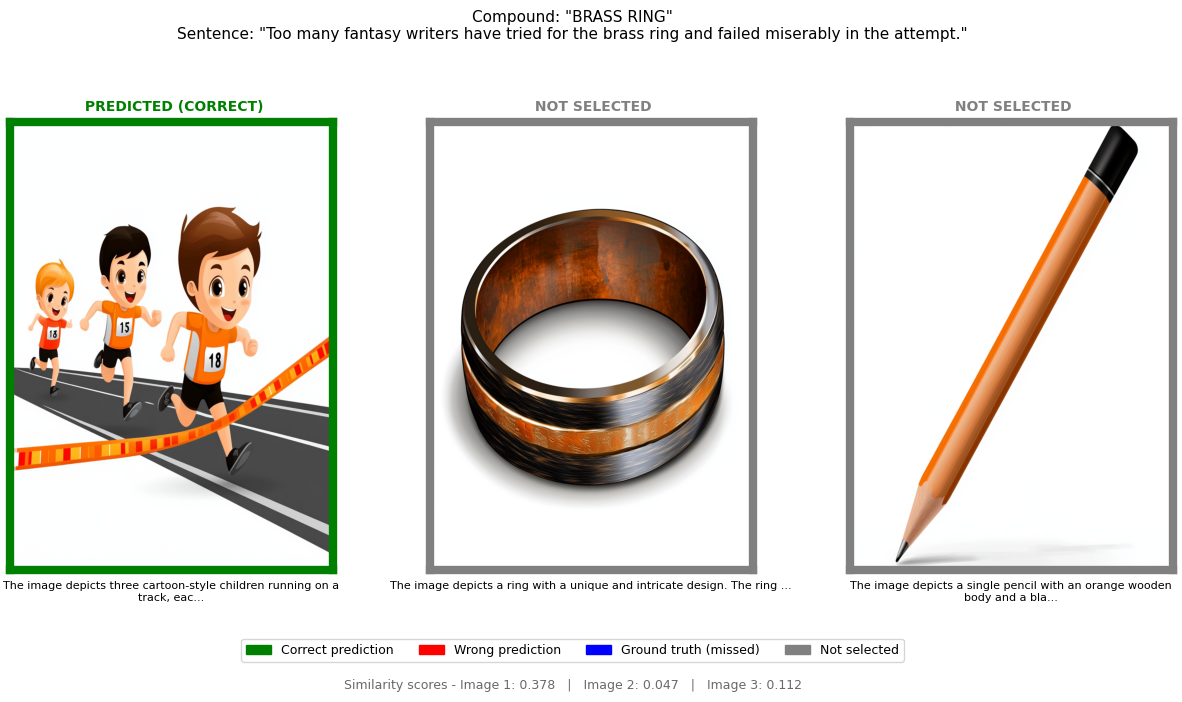

----------------------------------------------------------------------


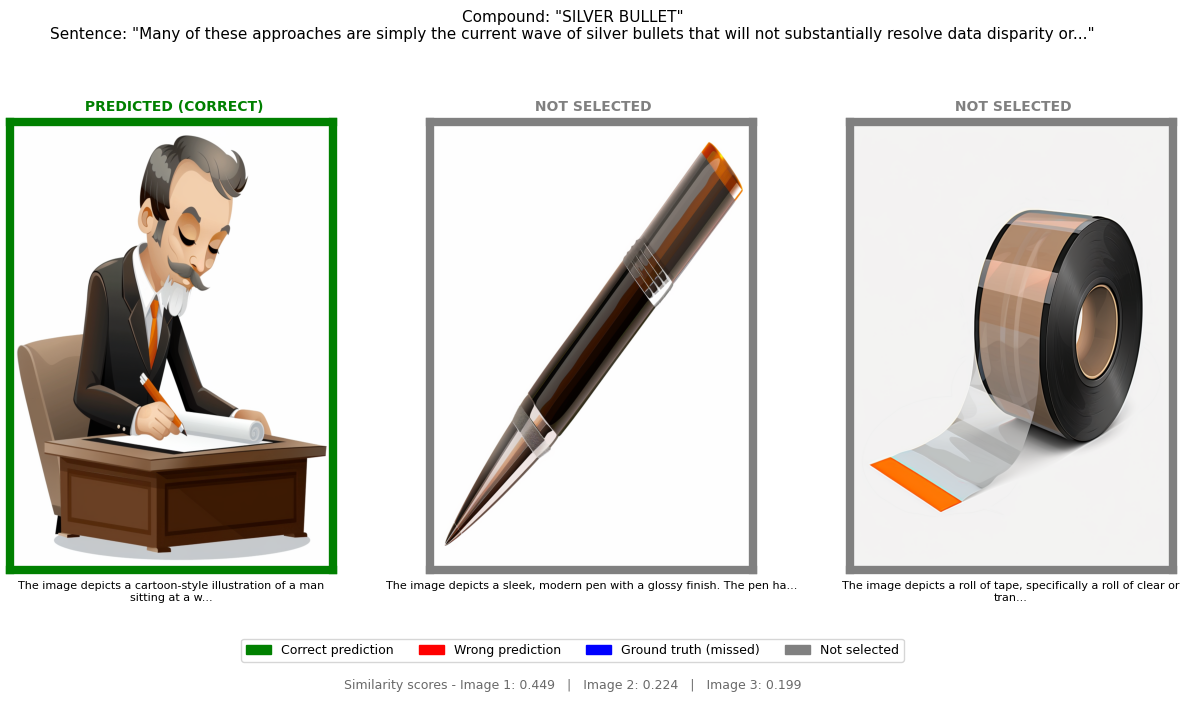

----------------------------------------------------------------------


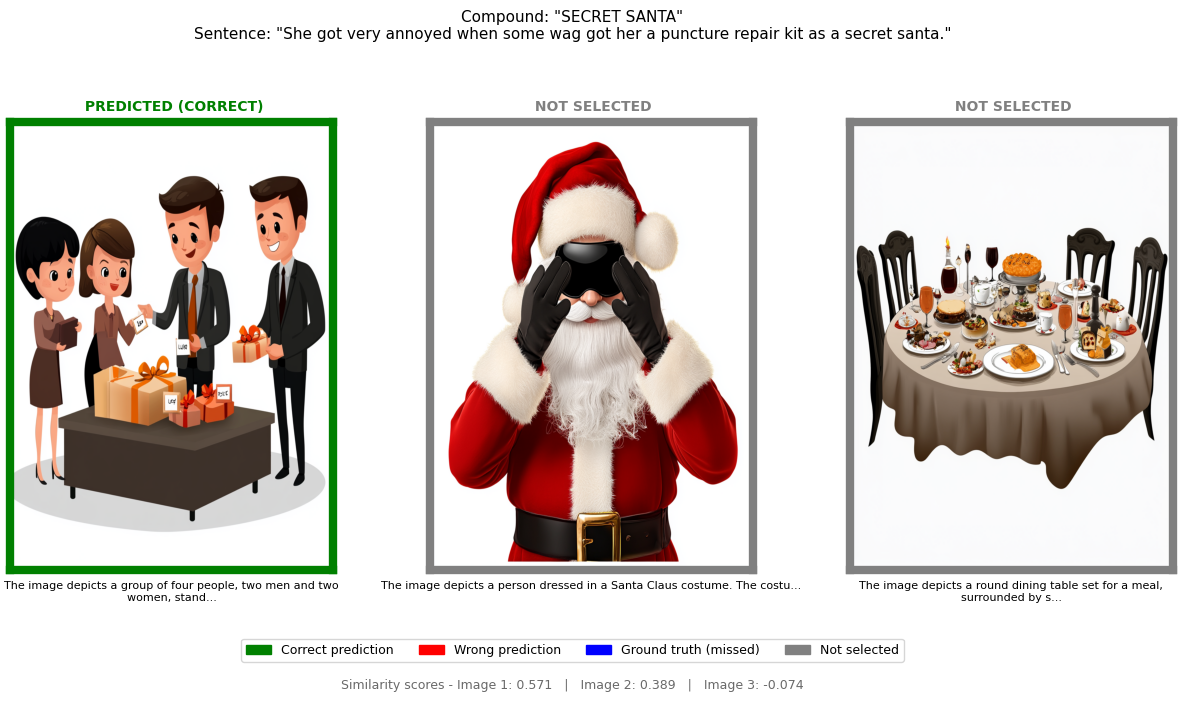

----------------------------------------------------------------------


In [ ]:
# DEMONSTRATION - Loads fine-tuned SBERT and predicts
# on random test samples

# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

'''
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
'''

fpath      = "/content/Task 2/"
test_path  = fpath + "test/test.csv"
img_folder = fpath + "test/images"
model_path = "/content/drive/MyDrive/Advanced_AI/sbert_finetuned"

# Load data and model
test_df   = pd.read_csv(test_path)
sbert_best = SentenceTransformer(model_path)
print(f"Model loaded from: {model_path}")
print(f"Test set: {len(test_df)} rows, {test_df['compound'].nunique()} compounds")

# Run demo
def run_demo(df, image_folder, n_compounds=3, model=sbert_best):
    all_compounds = df["compound"].unique().tolist()
    chosen        = random.sample(all_compounds, min(n_compounds, len(all_compounds)))

    for compound in chosen:
        group    = df[df["compound"] == compound].reset_index(drop=True)
        sentence = group["sentence"].iloc[0]
        captions = group["image_caption"].tolist()
        names    = group["image_name"].tolist()
        labels   = group["label"].tolist()

        # Run prediction
        embs     = model.encode([sentence] + captions, convert_to_numpy=True)
        sims     = cosine_similarity(embs[0:1], embs[1:])[0]
        pred_idx = int(np.argmax(sims))

        # Wrap sentence for display
        words         = sentence.split()
        sentence_wrap = " ".join(words[:20]) + ("..." if len(words) > 20 else "")

        fig = plt.figure(figsize=(15, 7))
        fig.suptitle(
            f'Compound: "{compound.upper()}"\nSentence: "{sentence_wrap}"',
            fontsize=11, y=0.98
        )

        for i in range(3):
            ax = fig.add_subplot(1, 3, i + 1)
            try:
                img = Image.open(os.path.join(image_folder, names[i])).convert("RGB")
                ax.imshow(img, aspect="auto")
            except Exception:
                ax.text(0.5, 0.5, "Image not found", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9)
                ax.set_facecolor("#f0f0f0")

            is_pred  = (i == pred_idx)
            is_truth = (labels[i] == 1)

            if is_pred and is_truth:
                border_color, status_text = "green", " PREDICTED (CORRECT)"
            elif is_pred and not is_truth:
                border_color, status_text = "red",   " PREDICTED (WRONG)"
            elif is_truth and not is_pred:
                border_color, status_text = "blue",  " GROUND TRUTH (MISSED)"
            else:
                border_color, status_text = "gray",  " NOT SELECTED"

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(6)

            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(status_text, fontsize=10, color=border_color, fontweight="bold", pad=8)
            caption_short = captions[i][:70] + "..." if len(captions[i]) > 70 else captions[i]
            ax.set_xlabel(caption_short, fontsize=8, labelpad=8, wrap=True, ha="center")

        sim_text = "   |   ".join([f"Image {i+1}: {sims[i]:.3f}" for i in range(3)])
        fig.text(0.5, 0.01, f"Similarity scores - {sim_text}", ha="center", fontsize=9, color="dimgray")

        legend_handles = [
            mpatches.Patch(color="green", label="Correct prediction"),
            mpatches.Patch(color="red",   label="Wrong prediction"),
            mpatches.Patch(color="blue",  label="Ground truth (missed)"),
            mpatches.Patch(color="gray",  label="Not selected"),
        ]
        fig.legend(handles=legend_handles, loc="lower center",
                   ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.04))

        plt.subplots_adjust(top=0.82, bottom=0.18, wspace=0.3)
        plt.show()
        print("-" * 70)

print("=" * 70)
print("DEMONSTRATION - Fine-tuned SBERT predictions on test data")
print("=" * 70)
run_demo(test_df, img_folder, n_compounds=3)

##Step 5: Report. Please write down your report in another document (together with Task 1)
.